# Make ROI Masks
Separate binary masks into individual cluster images and visualize each cluster.

In [1]:
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
from scipy import ndimage
from nilearn import plotting, image
from pathlib import Path

Matplotlib is building the font cache; this may take a moment.


In [2]:
base_dir = Path('nifti_roi-masks_fig03')

masks = {
    'fig03C_conjunc': base_dir / 'fig03C' / 'conjunc_POSxNEG_minTestStat_bin.nii.gz',
    'fig03D_contrast': base_dir / 'fig03D' / 'C_POSvsNEG_kda10_clust_tstat1_bin.nii.gz',
}

In [5]:
def separate_clusters(mask_path, min_size=50):
    """Return a list of single-cluster Nifti1Image objects with at least
    `min_size` voxels.
    """
    img = nib.load(mask_path)
    data = img.get_fdata()

    # Label connected components
    labeled, n_clusters = ndimage.label(data > 0)
    print(f'{mask_path.name}: {n_clusters} cluster(s) found')

    # Count voxels in each label (label 0 is background)
    cluster_sizes = np.bincount(labeled.ravel())

    cluster_imgs = []
    kept = 0

    for i in range(1, n_clusters + 1):
        if cluster_sizes[i] >= min_size:
            cluster_data = (labeled == i).astype(np.int8)
            cluster_imgs.append(
                nib.Nifti1Image(cluster_data, img.affine, img.header)
            )
            kept += 1

    print(f'  Kept {kept} cluster(s) with ≥ {min_size} voxels')

    return cluster_imgs


def plot_clusters(cluster_imgs, mask_name):
    """Plot each cluster with 10 evenly spaced z slices."""
    for i, cimg in enumerate(cluster_imgs, start=1):
        fig, ax = plt.subplots(figsize=(14, 3))
        display = plotting.plot_roi(
            cimg,
            display_mode='z',
            cut_coords=10,
            title=f'{mask_name} — cluster {i}',
            axes=ax,
        )
        plt.tight_layout()
        plt.show()

In [6]:
# fig03C — conjunc_POSxNEG_minTestStat_bin
clusters_fig03C = separate_clusters(masks['fig03C_conjunc'])

conjunc_POSxNEG_minTestStat_bin.nii.gz: 34 cluster(s) found
  Kept 4 cluster(s) with ≥ 50 voxels


/tmp/ipykernel_13266/2823144523.py:42: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


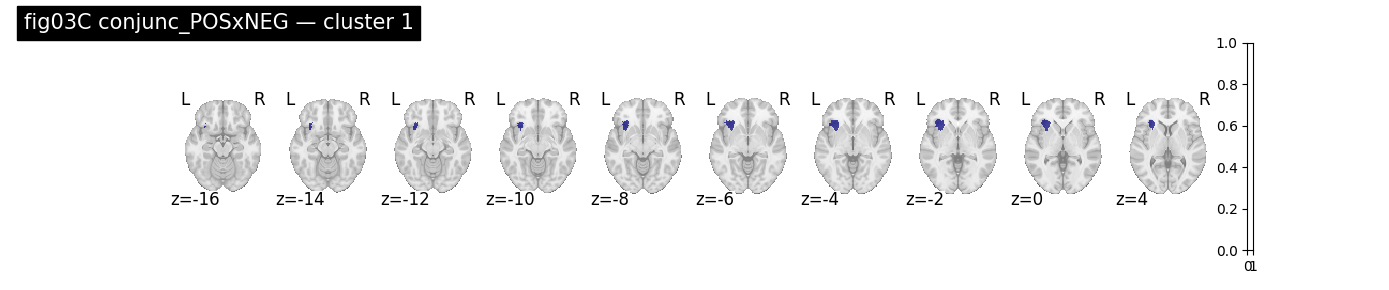

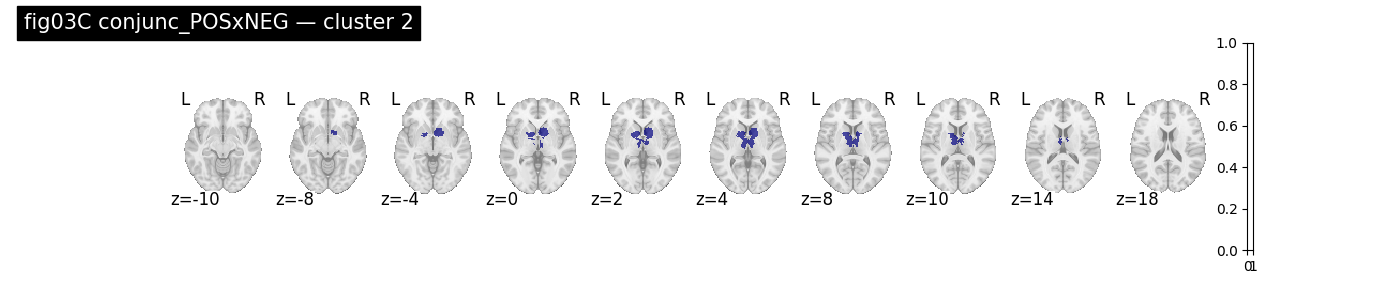

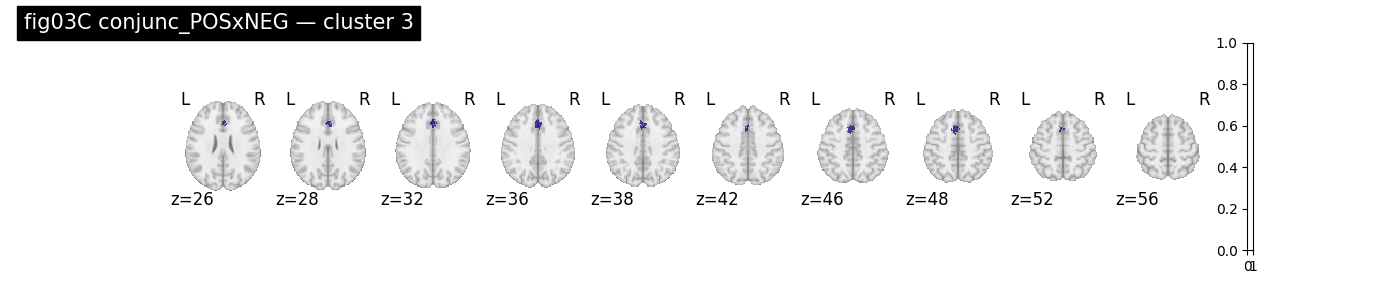

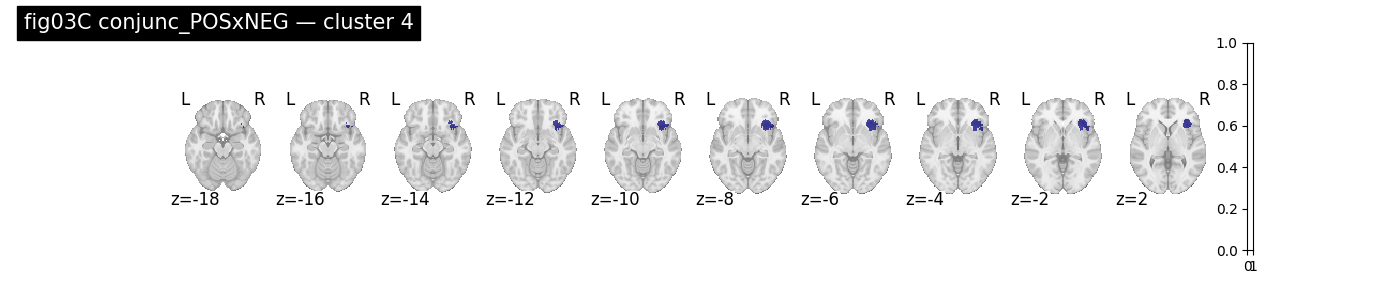

In [7]:

plot_clusters(clusters_fig03C, 'fig03C conjunc_POSxNEG')

C_POSvsNEG_kda10_clust_tstat1_bin.nii.gz: 41 cluster(s) found
  Kept 3 cluster(s) with ≥ 50 voxels


/tmp/ipykernel_13266/2823144523.py:42: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


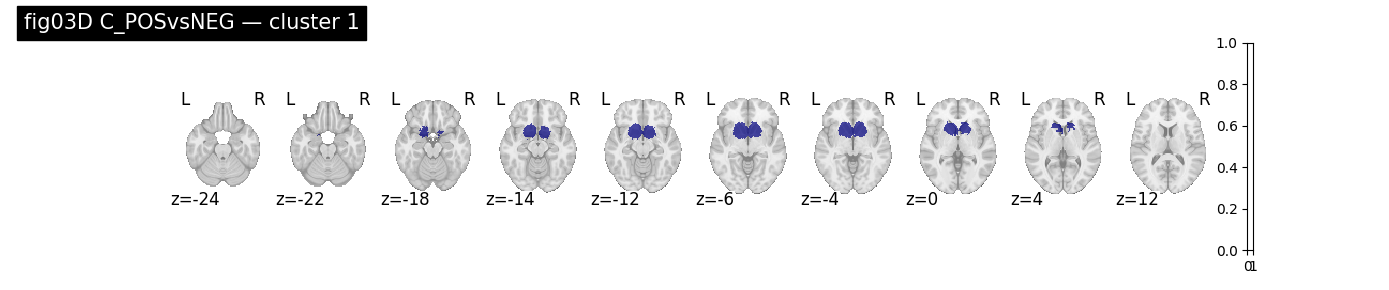

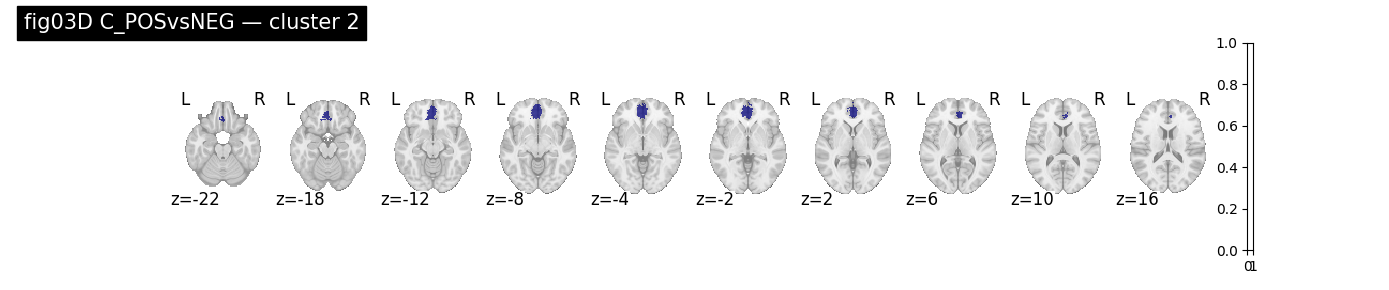

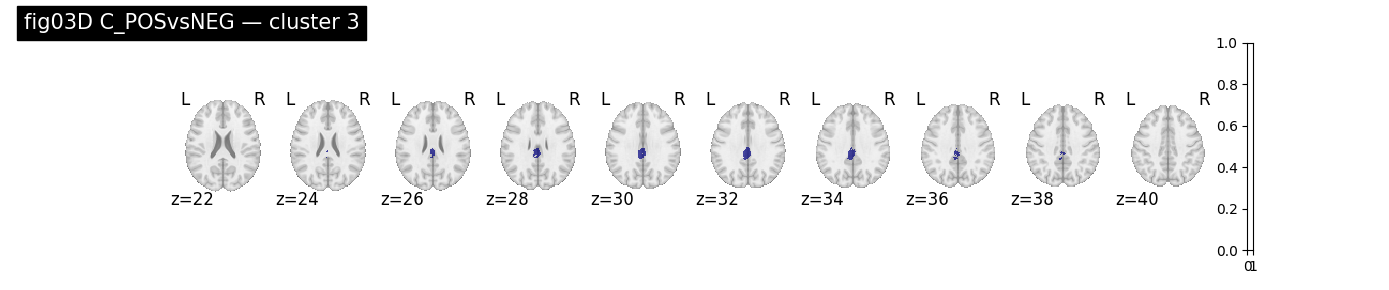

In [8]:
# fig03D — C_POSvsNEG_kda10_clust_tstat1_bin
clusters_fig03D = separate_clusters(masks['fig03D_contrast'])
plot_clusters(clusters_fig03D, 'fig03D C_POSvsNEG')